In [1]:
fpath=(r'C:\Users\sa01ld\OneDrive - SAMS\Cruises\SDA057-POLOMINTS-IRONMAN\Glider\SG647\pre-deployment\simdives\5thAugustResults.txt')

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt


# Load file
with open(fpath, "r") as file:
    lines = file.readlines()

data = []

for line in lines:
    # Common fields
    filename, rest = line.strip().split(":", 1)
    timestamp_str, rest = rest.split(",", 1)
    timestamp = float(timestamp_str)

    if "Roll commanded from" in rest:
        match = re.search(r"Roll commanded from ([\-\d.]+) deg.* to ([\-\d.]+) deg", rest)
        if match:
            data.append({
                "filename": filename,
                "timestamp": timestamp,
                "event_type": "commanded",
                "start_deg": float(match.group(1)),
                "end_deg": float(match.group(2)),
            })
    elif "Roll: No motion occurred." in rest:
        data.append({
            "filename": filename,
            "timestamp": timestamp,
            "event_type": "no_motion",
        })
    elif "Roll completed from" in rest:
        match = re.search(
            r"Roll completed from ([\-\d.]+) deg.* to ([\-\d.]+) deg.* took ([\d.]+) sec (\d+) mA \((\d+) mA peak\) ([\d.]+) Vmin ([\d.]+) AD/sec (\d+) ticks",
            rest
        )
        if match:
            data.append({
                "filename": filename,
                "timestamp": timestamp,
                "event_type": "completed",
                "start_deg": float(match.group(1)),
                "end_deg": float(match.group(2)),
                "duration_sec": float(match.group(3)),
                "avg_current_mA": int(match.group(4)),
                "peak_current_mA": int(match.group(5)),
                "vmin": float(match.group(6)),
                "ad_per_sec": float(match.group(7)),
                "ticks": int(match.group(8)),
            })

# Create DataFrame
df = pd.DataFrame(data)

# Show the DataFrame
print(df.head())


       filename  timestamp event_type  start_deg  end_deg  duration_sec  \
0  p6470001.cap    446.132  commanded       0.65     0.00           NaN   
1  p6470001.cap    447.839  no_motion        NaN      NaN           NaN   
2  p6470001.cap    617.826  commanded       0.65     0.00           NaN   
3  p6470001.cap    619.572  no_motion        NaN      NaN           NaN   
4  p6470001.cap     78.801  completed       0.68   -29.51           1.8   

   avg_current_mA  peak_current_mA  vmin  ad_per_sec  ticks  
0             NaN              NaN   NaN         NaN    NaN  
1             NaN              NaN   NaN         NaN    NaN  
2             NaN              NaN   NaN         NaN    NaN  
3             NaN              NaN   NaN         NaN    NaN  
4            74.0            142.0  14.6      601.69   71.0  


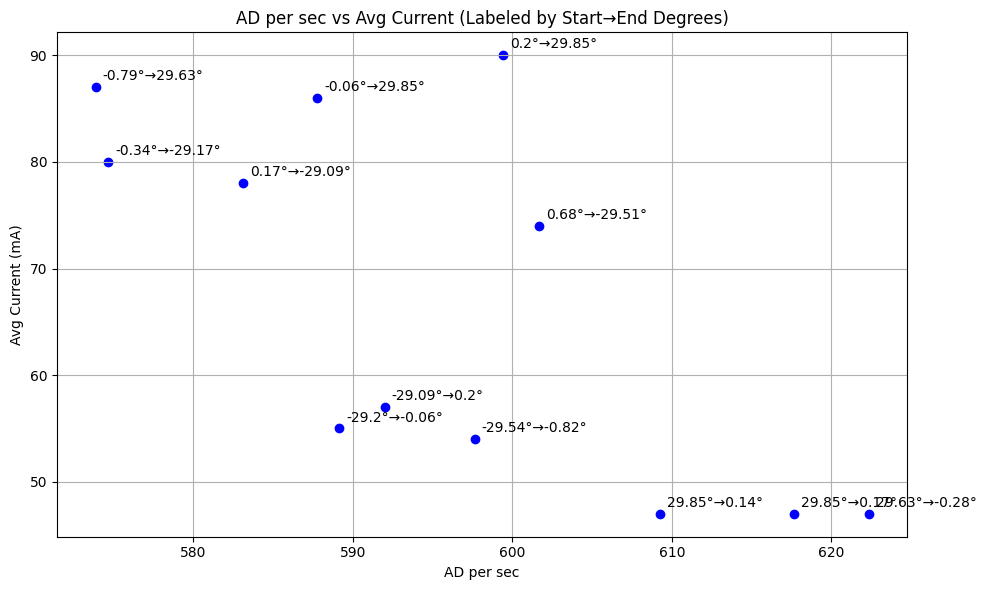

In [18]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(df["ad_per_sec"], df["avg_current_mA"], color='blue')

# Add labels
for i, row in df.iterrows():
    label = f'{row["start_deg"]}°→{row["end_deg"]}°'
    plt.annotate(label, (row["ad_per_sec"], row["avg_current_mA"]), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel("AD per sec")
plt.ylabel("Avg Current (mA)")
plt.title("AD per sec vs Avg Current (Labeled by Start→End Degrees)")
plt.grid(True)
plt.tight_layout()
plt.show()